# 05 — Forecasting: Monthly Card Spend

Feeds **report §7**. Forecasts total monthly card spend for the portfolio. The
series is built from the transaction ledger; partial end-months are trimmed (the
data ends mid-month on 2014-03-28). The last 3 months are held out to compare a
moving-average baseline against ARIMA; the winner forecasts 3 months ahead.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
PROC = ROOT / "data" / "processed"

metrics = json.load(open(ROOT / "metrics" / "forecasting.json"))
fc = pd.read_parquet(PROC / "spend_forecast.parquet")
fc["month"] = pd.to_datetime(fc["month"])
print("full months:", metrics["n_months"], "| best:", metrics["best_method"],
      "| holdout:", metrics["test_months"], "months")

full months: 23 | best: moving_average | holdout: 3 months


## 7.1 Method comparison (3-month holdout)

In [2]:
cmp = pd.DataFrame(metrics["by_method"]).T[["mape", "rmse"]]
cmp.columns = ["MAPE (%)", "RMSE ($)"]
cmp.sort_values("MAPE (%)")

,MAPE (%),RMSE ($)
moving_average,12.808,"780,380.036"
arima,13.242,"844,456.890"


On this short, roughly flat series the **moving-average baseline (MAPE 12.8%)
narrowly beats ARIMA (13.2%)** — a useful reminder that simple methods are hard
to beat when there is no strong trend or seasonality and only ~2 years of data.
We forecast with the moving average and report the ~13% error honestly.

## 7.2 Spend forecast

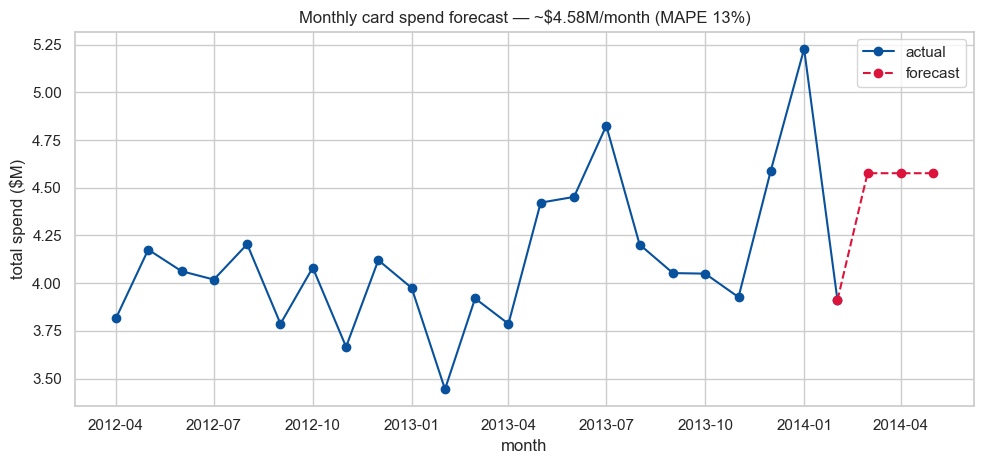

,month,spend
23,2014-03-01,"4,576,122.000"
24,2014-04-01,"4,576,122.000"
25,2014-05-01,"4,576,122.000"


In [3]:
hist = fc[fc["kind"] == "actual"]
fut = fc[fc["kind"] == "forecast"]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(hist["month"], hist["spend"]/1e6, marker="o", color="#08519c", label="actual")
bridge = pd.concat([hist.iloc[[-1]], fut])
ax.plot(bridge["month"], bridge["spend"]/1e6, marker="o", ls="--", color="crimson", label="forecast")
ax.set(xlabel="month", ylabel="total spend ($M)",
       title=f"Monthly card spend forecast — ~${fut['spend'].mean()/1e6:.2f}M/month (MAPE {metrics['by_method'][metrics['best_method']]['mape']:.0f}%)")
ax.legend(); plt.tight_layout(); plt.show()
fut.assign(spend=fut["spend"].round(0))[["month", "spend"]]

**Business interpretation → §8.** Portfolio spend is stable at roughly
**$4.6M per month** with no material trend, so revenue planning can assume a
flat run-rate over the short horizon (±13%). The forecast is a planning baseline,
not a precision instrument — the wide band reflects genuine month-to-month
volatility and the short history. With more history, a seasonal model (e.g.
SARIMA with a 12-month cycle) should be revisited to capture holiday effects.